<a href="https://colab.research.google.com/github/shivashree2121-gif/AI-Resume-Matching-System/blob/main/app_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pypdf python-docx scikit-learn nltk pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.1/385.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 17.8 MB/s eta 0:00:00


In [3]:
import re
import string
import numpy as np
import pandas as pd

from pypdf import PdfReader
from docx import Document

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

STOP_WORDS = set(stopwords.words("english"))

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Shivashree_Jayachandran_Resume.pdf to Shivashree_Jayachandran_Resume.pdf


In [5]:
file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

if file_name.lower().endswith(".pdf"):

    reader = PdfReader(file_name)

    resume_text = ""

    for page in reader.pages:
        text = page.extract_text()

        if text:
            resume_text += text + "\n"

elif file_name.lower().endswith(".docx"):

    document = Document(file_name)

    resume_text = ""

    for paragraph in document.paragraphs:
        resume_text += paragraph.text + "\n"

else:
    raise ValueError("Please upload a PDF or DOCX file.")

print("\n========== RESUME TEXT ==========\n")
print(resume_text)

Uploaded file: Shivashree_Jayachandran_Resume.pdf

========== RESUME TEXT ==========

SHIVASHREE JAYACHANDRAN
Business Analyst | Workflow & Process Improvement | Data & Reporting
Salem, India  |  9751576605  |  shivashree2121@gmail.com  |  linkedin.com/in/shiva-shree-36108b255
PROFESSIONAL SUMMARY
Detail-oriented Business Analyst with hands-on experience mapping, monitoring, and improving high-volume operational processes
in a KPI-driven environment. Skilled in analyzing end-to-end workflows, identifying process bottlenecks, and translating data into
actionable recommendations using Power BI, Excel, and SQL. Strong track record of building tracking systems that improve
process visibility, streamline reporting, and support cross-functional decision-making. Adaptable and eager to apply analytical,
problem-solving, and communication skills across business analyst, operations, and data-focused roles. Currently pursuing an
MCA to deepen expertise in data-driven process improvement and busin

In [6]:
def clean_text(text):

    # Convert everything to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in STOP_WORDS
    ]

    # Join words back together
    cleaned_text = " ".join(words)

    return cleaned_text


cleaned_resume = clean_text(resume_text)

print("========== CLEANED RESUME ==========\n")
print(cleaned_resume)

========== CLEANED RESUME ==========

shivashree jayachandran business analyst workflow process improvement data reporting salem india linkedincominshivashree b professional summary detailoriented business analyst handson experience mapping monitoring improving highvolume operational processes kpidriven environment skilled analyzing endtoend workflows identifying process bottlenecks translating data actionable recommendations using power bi excel sql strong track record building tracking systems improve process visibility streamline reporting support crossfunctional decisionmaking adaptable eager apply analytical problemsolving communication skills across business analyst operations datafocused roles currently pursuing mca deepen expertise datadriven process improvement business analytics core skills  process workflow analysis process mapping documentation bottleneck identification rootcause analysis  data analysis reporting power bi microsoft excel advanced sql progress python panda

In [7]:
job_description = """
We are looking for a Data Analyst who has strong knowledge
of Python, SQL, Excel, Power BI and Tableau.

The candidate should have experience in data analysis,
data visualization, statistics, machine learning and
working with large datasets.

Knowledge of Pandas, NumPy and scikit-learn is preferred.
"""

print(job_description)


We are looking for a Data Analyst who has strong knowledge
of Python, SQL, Excel, Power BI and Tableau.

The candidate should have experience in data analysis,
data visualization, statistics, machine learning and
working with large datasets.

Knowledge of Pandas, NumPy and scikit-learn is preferred.



In [8]:
cleaned_job = clean_text(job_description)

print("========== CLEANED JOB DESCRIPTION ==========\n")
print(cleaned_job)

========== CLEANED JOB DESCRIPTION ==========

looking data analyst strong knowledge python sql excel power bi tableau candidate experience data analysis data visualization statistics machine learning working large datasets knowledge pandas numpy scikitlearn preferred


In [9]:
vectorizer = TfidfVectorizer()

documents = [
    cleaned_resume,
    cleaned_job
]

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (2, 250)


In [10]:
similarity = cosine_similarity(
    tfidf_matrix[0:1],
    tfidf_matrix[1:2]
)

similarity_score = similarity[0][0] * 100

print(f"Resume–Job Similarity: {similarity_score:.2f}%")

Resume–Job Similarity: 20.17%


In [11]:
skills = [
    # Programming
    "python",
    "java",
    "r",
    "c++",

    # Databases
    "sql",
    "mysql",
    "postgresql",
    "mongodb",

    # Data Analysis
    "excel",
    "power bi",
    "tableau",
    "pandas",
    "numpy",

    # Machine Learning
    "machine learning",
    "deep learning",
    "scikit-learn",
    "tensorflow",
    "pytorch",

    # Statistics
    "statistics",
    "hypothesis testing",
    "regression",
    "probability",

    # Data / AI
    "data analysis",
    "data visualization",
    "nlp",
    "artificial intelligence",

    # Cloud
    "aws",
    "azure",
    "google cloud",

    # Tools
    "git",
    "github",
    "docker"
]

print("Total skills in database:", len(skills))

Total skills in database: 32


In [12]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills:

        if skill in text:
            found_skills.append(skill)

    return sorted(set(found_skills))

In [13]:
resume_skills = extract_skills(resume_text)

print("========== RESUME SKILLS ==========\n")

for skill in resume_skills:
    print("✓", skill)

========== RESUME SKILLS ==========

✓ data analysis
✓ excel
✓ machine learning
✓ numpy
✓ pandas
✓ power bi
✓ python
✓ r
✓ sql


In [14]:
job_skills = extract_skills(job_description)

print("========== REQUIRED JOB SKILLS ==========\n")

for skill in job_skills:
    print("•", skill)

========== REQUIRED JOB SKILLS ==========

• data analysis
• data visualization
• excel
• machine learning
• numpy
• pandas
• power bi
• python
• r
• scikit-learn
• sql
• statistics
• tableau


In [15]:
matched_skills = sorted(
    set(resume_skills) &
    set(job_skills)
)

print("========== MATCHED SKILLS ==========\n")

for skill in matched_skills:
    print("✓", skill)

========== MATCHED SKILLS ==========

✓ data analysis
✓ excel
✓ machine learning
✓ numpy
✓ pandas
✓ power bi
✓ python
✓ r
✓ sql


In [16]:
missing_skills = sorted(
    set(job_skills) -
    set(resume_skills)
)

print("========== MISSING SKILLS ==========\n")

for skill in missing_skills:
    print("✗", skill)

========== MISSING SKILLS ==========

✗ data visualization
✗ scikit-learn
✗ statistics
✗ tableau


In [17]:
if len(job_skills) > 0:

    skill_score = (
        len(matched_skills) /
        len(job_skills)
    ) * 100

else:

    skill_score = 0

print(f"Skill Match Score: {skill_score:.2f}%")

Skill Match Score: 69.23%


In [18]:
# Text similarity score from Step 7
text_score = similarity_score

# Skill score from Step 8
skill_score = skill_score

# Weighted final score
final_score = (
    (text_score * 0.60) +
    (skill_score * 0.40)
)

print("========== FINAL RESULT ==========\n")

print(f"Text Similarity Score : {text_score:.2f}%")
print(f"Skill Match Score     : {skill_score:.2f}%")
print(f"Final Match Score     : {final_score:.2f}%")

========== FINAL RESULT ==========

Text Similarity Score : 20.17%
Skill Match Score     : 69.23%
Final Match Score     : 39.79%


In [19]:
def get_recommendation(score):

    if score >= 80:
        return "Excellent Match - Strongly Recommended"

    elif score >= 65:
        return "Good Match - Recommended"

    elif score >= 50:
        return "Moderate Match - Consider Improving Skills"

    else:
        return "Low Match - Significant Skill Gaps"


recommendation = get_recommendation(final_score)

print("Recommendation:", recommendation)

Recommendation: Low Match - Significant Skill Gaps


In [20]:
print("=" * 60)
print("             AI RESUME MATCHING REPORT")
print("=" * 60)

print(f"\n📊 Text Similarity     : {text_score:.2f}%")
print(f"🛠️ Skill Match          : {skill_score:.2f}%")
print(f"🎯 Overall Match       : {final_score:.2f}%")

print("\n✅ MATCHED SKILLS")
print("-" * 30)

for skill in matched_skills:
    print("✓", skill)

print("\n❌ MISSING SKILLS")
print("-" * 30)

for skill in missing_skills:
    print("✗", skill)

print("\n💡 RECOMMENDATION")
print("-" * 30)

print(recommendation)

print("\n" + "=" * 60)

             AI RESUME MATCHING REPORT

📊 Text Similarity     : 20.17%
🛠️ Skill Match          : 69.23%
🎯 Overall Match       : 39.79%

✅ MATCHED SKILLS
------------------------------
✓ data analysis
✓ excel
✓ machine learning
✓ numpy
✓ pandas
✓ power bi
✓ python
✓ r
✓ sql

❌ MISSING SKILLS
------------------------------
✗ data visualization
✗ scikit-learn
✗ statistics
✗ tableau

💡 RECOMMENDATION
------------------------------
Low Match - Significant Skill Gaps



In [21]:
candidate_resumes = {

    "Candidate 1": """
    Data Analyst with experience in Python, SQL, Excel,
    Power BI, Pandas, NumPy and statistics.
    Experienced in data analysis and data visualization.
    """,

    "Candidate 2": """
    Business Analyst skilled in Excel, SQL, Tableau,
    Power BI and statistics.
    Experienced in reporting and business intelligence.
    """,

    "Candidate 3": """
    Data Scientist with Python, SQL, Pandas, NumPy,
    Machine Learning, Scikit-learn, statistics and
    data visualization.
    """
}

print("Number of candidates:", len(candidate_resumes))

Number of candidates: 3


In [22]:
def calculate_candidate_score(resume, job):

    # Clean text
    resume_clean = clean_text(resume)
    job_clean = clean_text(job)

    # TF-IDF
    vectorizer = TfidfVectorizer()

    matrix = vectorizer.fit_transform([
        resume_clean,
        job_clean
    ])

    similarity = cosine_similarity(
        matrix[0:1],
        matrix[1:2]
    )[0][0] * 100

    # Skills
    resume_skills = extract_skills(resume)
    job_skills = extract_skills(job)

    matched = sorted(
        set(resume_skills) &
        set(job_skills)
    )

    missing = sorted(
        set(job_skills) -
        set(resume_skills)
    )

    # Skill score
    if len(job_skills) > 0:

        skill_score = (
            len(matched) /
            len(job_skills)
        ) * 100

    else:

        skill_score = 0

    # Final score
    final_score = (
        similarity * 0.60 +
        skill_score * 0.40
    )

    return {
        "Text Similarity": round(similarity, 2),
        "Skill Match": round(skill_score, 2),
        "Final Score": round(final_score, 2),
        "Matched Skills": matched,
        "Missing Skills": missing
    }

In [23]:
ranking = []

for candidate, resume in candidate_resumes.items():

    result = calculate_candidate_score(
        resume,
        job_description
    )

    ranking.append({
        "Candidate": candidate,
        "Text Similarity": result["Text Similarity"],
        "Skill Match": result["Skill Match"],
        "Final Score": result["Final Score"]
    })


ranking_df = pd.DataFrame(ranking)

ranking_df = ranking_df.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

ranking_df.index = ranking_df.index + 1

print(ranking_df)

     Candidate  Text Similarity  Skill Match  Final Score
1  Candidate 1            61.57        76.92        67.71
2  Candidate 3            52.97        69.23        59.47
3  Candidate 2            18.28        46.15        29.43


In [24]:
ranking_df

,Candidate,Text Similarity,Skill Match,Final Score
1,Candidate 1,61.57,76.92,67.71
2,Candidate 3,52.97,69.23,59.47
3,Candidate 2,18.28,46.15,29.43


In [25]:
top_candidate = ranking_df.iloc[0]

print("🏆 TOP CANDIDATE")
print("-" * 40)

print("Candidate:", top_candidate["Candidate"])
print("Final Score:", top_candidate["Final Score"], "%")

🏆 TOP CANDIDATE
----------------------------------------
Candidate: Candidate 1
Final Score: 67.71 %


In [26]:
for candidate, resume in candidate_resumes.items():

    result = calculate_candidate_score(
        resume,
        job_description
    )

    print("\n" + "=" * 50)
    print(candidate)
    print("=" * 50)

    print(
        "Final Score:",
        result["Final Score"],
        "%"
    )

    print("\n✅ Matched Skills:")

    for skill in result["Matched Skills"]:
        print("  ✓", skill)

    print("\n❌ Missing Skills:")

    for skill in result["Missing Skills"]:
        print("  ✗", skill)


Candidate 1
Final Score: 67.71 %

✅ Matched Skills:
  ✓ data analysis
  ✓ data visualization
  ✓ excel
  ✓ numpy
  ✓ pandas
  ✓ power bi
  ✓ python
  ✓ r
  ✓ sql
  ✓ statistics

❌ Missing Skills:
  ✗ machine learning
  ✗ scikit-learn
  ✗ tableau

Candidate 2
Final Score: 29.43 %

✅ Matched Skills:
  ✓ excel
  ✓ power bi
  ✓ r
  ✓ sql
  ✓ statistics
  ✓ tableau

❌ Missing Skills:
  ✗ data analysis
  ✗ data visualization
  ✗ machine learning
  ✗ numpy
  ✗ pandas
  ✗ python
  ✗ scikit-learn

Candidate 3
Final Score: 59.47 %

✅ Matched Skills:
  ✓ data visualization
  ✓ machine learning
  ✓ numpy
  ✓ pandas
  ✓ python
  ✓ r
  ✓ scikit-learn
  ✓ sql
  ✓ statistics

❌ Missing Skills:
  ✗ data analysis
  ✗ excel
  ✗ power bi
  ✗ tableau


In [27]:
from google.colab import files

uploaded_resumes = files.upload()

print("\nUploaded resumes:")
for file_name in uploaded_resumes.keys():
    print("📄", file_name)

Saving Shivashree_Jayachandran_Resume.pdf to Shivashree_Jayachandran_Resume (1).pdf
Saving Shivashree_Jayachandran_Business_Workflow_Analyst_Resume.pdf to Shivashree_Jayachandran_Business_Workflow_Analyst_Resume.pdf

Uploaded resumes:
📄 Shivashree_Jayachandran_Resume (1).pdf
📄 Shivashree_Jayachandran_Business_Workflow_Analyst_Resume.pdf


In [28]:
candidate_texts = {}

for file_name in uploaded_resumes.keys():

    try:

        if file_name.lower().endswith(".pdf"):

            reader = PdfReader(file_name)

            text = ""

            for page in reader.pages:

                page_text = page.extract_text()

                if page_text:
                    text += page_text + "\n"

        elif file_name.lower().endswith(".docx"):

            document = Document(file_name)

            text = ""

            for paragraph in document.paragraphs:
                text += paragraph.text + "\n"

        else:

            print(f"⚠️ Skipping unsupported file: {file_name}")
            continue

        candidate_texts[file_name] = text

        print(f"✅ Extracted: {file_name}")

    except Exception as e:

        print(f"❌ Error reading {file_name}: {e}")

✅ Extracted: Shivashree_Jayachandran_Resume (1).pdf
✅ Extracted: Shivashree_Jayachandran_Business_Workflow_Analyst_Resume.pdf


In [29]:
for file_name, text in candidate_texts.items():

    print("\n" + "=" * 60)
    print("📄", file_name)
    print("=" * 60)

    print(text[:500])


📄 Shivashree_Jayachandran_Resume (1).pdf
SHIVASHREE JAYACHANDRAN
Business Analyst | Workflow & Process Improvement | Data & Reporting
Salem, India  |  9751576605  |  shivashree2121@gmail.com  |  linkedin.com/in/shiva-shree-36108b255
PROFESSIONAL SUMMARY
Detail-oriented Business Analyst with hands-on experience mapping, monitoring, and improving high-volume operational processes
in a KPI-driven environment. Skilled in analyzing end-to-end workflows, identifying process bottlenecks, and translating data into
actionable recommendations us

📄 Shivashree_Jayachandran_Business_Workflow_Analyst_Resume.pdf
SHIVASHREE JAYACHANDRAN
Business Workflow Analyst
Salem, India  •  9751576605  •  shivashree2121@gmail.com  •  LinkedIn
PROFESSIONAL SUMMARY
Detail-oriented Business Workflow Analyst with hands-on experience mapping, monitoring, and improving high-volume 
operational processes in a KPI-driven environment. Skilled in analyzing end-to-end workflows, identifying process 
bottlenecks, and trans

In [30]:
real_ranking = []

for file_name, resume_text in candidate_texts.items():

    result = calculate_candidate_score(
        resume_text,
        job_description
    )

    real_ranking.append({

        "Resume": file_name,

        "Text Similarity":
            result["Text Similarity"],

        "Skill Match":
            result["Skill Match"],

        "Final Score":
            result["Final Score"],

        "Matched Skills":
            ", ".join(result["Matched Skills"]),

        "Missing Skills":
            ", ".join(result["Missing Skills"])
    })


real_ranking_df = pd.DataFrame(real_ranking)

real_ranking_df = real_ranking_df.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

real_ranking_df.index = real_ranking_df.index + 1

real_ranking_df

,Resume,Text Similarity,Skill Match,Final Score,Matched Skills,Missing Skills
1,Shivashree_Jayachandran_Business_Workflow_Anal...,21.78,69.23,40.76,"data analysis, excel, machine learning, numpy,...","data visualization, scikit-learn, statistics, ..."
2,Shivashree_Jayachandran_Resume (1).pdf,20.17,69.23,39.79,"data analysis, excel, machine learning, numpy,...","data visualization, scikit-learn, statistics, ..."


In [31]:
best_candidate = real_ranking_df.iloc[0]

print("🏆 BEST MATCH")
print("=" * 50)

print("Resume:", best_candidate["Resume"])
print("Final Score:", best_candidate["Final Score"], "%")

print("\n✅ Matched Skills:")
print(best_candidate["Matched Skills"])

print("\n❌ Missing Skills:")
print(best_candidate["Missing Skills"])

🏆 BEST MATCH
Resume: Shivashree_Jayachandran_Business_Workflow_Analyst_Resume.pdf
Final Score: 40.76 %

✅ Matched Skills:
data analysis, excel, machine learning, numpy, pandas, power bi, python, r, sql

❌ Missing Skills:
data visualization, scikit-learn, statistics, tableau


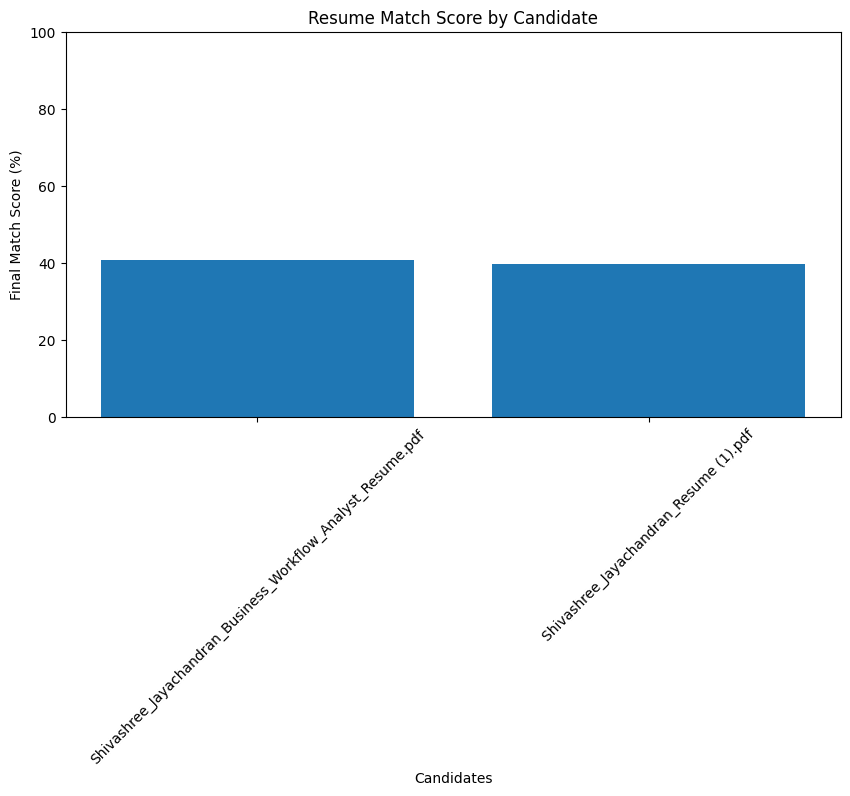

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    real_ranking_df["Resume"],
    real_ranking_df["Final Score"]
)

plt.xlabel("Candidates")
plt.ylabel("Final Match Score (%)")
plt.title("Resume Match Score by Candidate")

plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()

In [33]:
comparison_df = real_ranking_df[
    ["Resume", "Text Similarity", "Skill Match"]
].copy()

comparison_df

,Resume,Text Similarity,Skill Match
1,Shivashree_Jayachandran_Business_Workflow_Anal...,21.78,69.23
2,Shivashree_Jayachandran_Resume (1).pdf,20.17,69.23


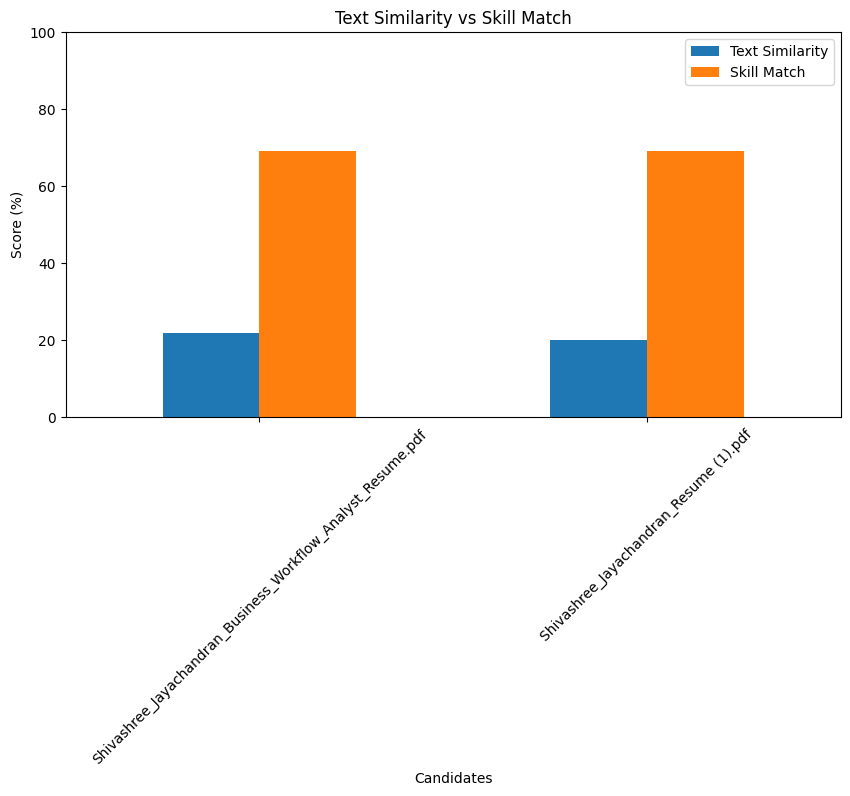

In [34]:
comparison_df.plot(
    x="Resume",
    y=["Text Similarity", "Skill Match"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Text Similarity vs Skill Match")
plt.xlabel("Candidates")
plt.ylabel("Score (%)")
plt.xticks(rotation=45)

plt.ylim(0, 100)

plt.show()

In [35]:
from collections import Counter

missing_skill_counter = Counter()

for file_name, resume_text in candidate_texts.items():

    result = calculate_candidate_score(
        resume_text,
        job_description
    )

    for skill in result["Missing Skills"]:

        missing_skill_counter[skill] += 1


missing_skills_df = pd.DataFrame(
    missing_skill_counter.items(),
    columns=["Skill", "Candidates Missing"]
)

missing_skills_df = missing_skills_df.sort_values(
    by="Candidates Missing",
    ascending=False
)

missing_skills_df

,Skill,Candidates Missing
0,data visualization,2
1,scikit-learn,2
2,statistics,2
3,tableau,2


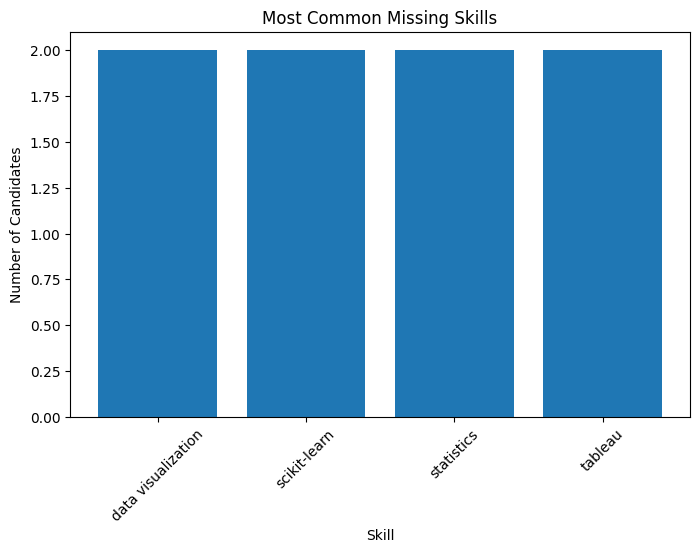

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    missing_skills_df["Skill"],
    missing_skills_df["Candidates Missing"]
)

plt.xlabel("Skill")
plt.ylabel("Number of Candidates")
plt.title("Most Common Missing Skills")

plt.xticks(rotation=45)

plt.show()

In [37]:
final_report = real_ranking_df[
    [
        "Resume",
        "Text Similarity",
        "Skill Match",
        "Final Score",
        "Matched Skills",
        "Missing Skills"
    ]
].copy()

final_report

,Resume,Text Similarity,Skill Match,Final Score,Matched Skills,Missing Skills
1,Shivashree_Jayachandran_Business_Workflow_Anal...,21.78,69.23,40.76,"data analysis, excel, machine learning, numpy,...","data visualization, scikit-learn, statistics, ..."
2,Shivashree_Jayachandran_Resume (1).pdf,20.17,69.23,39.79,"data analysis, excel, machine learning, numpy,...","data visualization, scikit-learn, statistics, ..."


In [38]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 73.0 MB/s eta 0:00:00


In [39]:
%%writefile app.py

import streamlit as st
import re
import string

from pypdf import PdfReader
from docx import Document

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

STOP_WORDS = set(stopwords.words("english"))

# ============================================================
# SKILL DATABASE
# ============================================================

skills = [
    "python",
    "java",
    "r",
    "c++",

    "sql",
    "mysql",
    "postgresql",
    "mongodb",

    "excel",
    "power bi",
    "tableau",
    "pandas",
    "numpy",

    "machine learning",
    "deep learning",
    "scikit-learn",
    "tensorflow",
    "pytorch",

    "statistics",
    "hypothesis testing",
    "regression",
    "probability",

    "data analysis",
    "data visualization",
    "nlp",
    "artificial intelligence",

    "aws",
    "azure",
    "google cloud",

    "git",
    "github",
    "docker"
]


# ============================================================
# TEXT EXTRACTION
# ============================================================

def extract_pdf_text(uploaded_file):

    reader = PdfReader(uploaded_file)

    text = ""

    for page in reader.pages:

        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"

    return text


def extract_docx_text(uploaded_file):

    document = Document(uploaded_file)

    text = ""

    for paragraph in document.paragraphs:

        text += paragraph.text + "\n"

    return text


def extract_text(uploaded_file):

    file_name = uploaded_file.name.lower()

    if file_name.endswith(".pdf"):

        return extract_pdf_text(uploaded_file)

    elif file_name.endswith(".docx"):

        return extract_docx_text(uploaded_file)

    else:

        return ""


# ============================================================
# TEXT CLEANING
# ============================================================

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'http\S+|www\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\S+@\S+',
        ' ',
        text
    )

    text = re.sub(
        r'\d+',
        ' ',
        text
    )

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in STOP_WORDS
    ]

    return " ".join(words)


# ============================================================
# SKILL EXTRACTION
# ============================================================

def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills:

        if skill in text:

            found_skills.append(skill)

    return sorted(set(found_skills))


# ============================================================
# RESUME MATCHING
# ============================================================

def calculate_candidate_score(resume, job):

    resume_clean = clean_text(resume)

    job_clean = clean_text(job)

    # TF-IDF
    vectorizer = TfidfVectorizer()

    matrix = vectorizer.fit_transform(
        [resume_clean, job_clean]
    )

    similarity = cosine_similarity(
        matrix[0:1],
        matrix[1:2]
    )[0][0] * 100

    # Skills
    resume_skills = extract_skills(resume)

    job_skills = extract_skills(job)

    matched = sorted(
        set(resume_skills) &
        set(job_skills)
    )

    missing = sorted(
        set(job_skills) -
        set(resume_skills)
    )

    # Skill score
    if len(job_skills) > 0:

        skill_score = (
            len(matched) /
            len(job_skills)
        ) * 100

    else:

        skill_score = 0

    # Final weighted score
    final_score = (
        similarity * 0.60 +
        skill_score * 0.40
    )

    return {
        "Text Similarity": round(similarity, 2),
        "Skill Match": round(skill_score, 2),
        "Final Score": round(final_score, 2),
        "Matched Skills": matched,
        "Missing Skills": missing
    }


# ============================================================
# STREAMLIT UI
# ============================================================

st.set_page_config(
    page_title="AI Resume Matcher",
    page_icon="📄",
    layout="wide"
)

st.title("📄 AI Resume–Job Matching System")

st.write(
    "Upload multiple resumes and compare them "
    "against a job description using NLP and Machine Learning."
)

st.divider()

# ------------------------------------------------------------
# Upload resumes
# ------------------------------------------------------------

st.subheader("📂 Upload Resumes")

uploaded_resumes = st.file_uploader(
    "Upload candidate resumes",
    type=["pdf", "docx"],
    accept_multiple_files=True
)

# ------------------------------------------------------------
# Job description
# ------------------------------------------------------------

st.subheader("💼 Job Description")

job_description = st.text_area(
    "Paste the job description here:",
    height=250
)

# ------------------------------------------------------------
# Analyze
# ------------------------------------------------------------

if st.button(
    "🚀 Analyze Candidates",
    type="primary"
):

    if not uploaded_resumes:

        st.error(
            "Please upload at least one resume."
        )

    elif not job_description.strip():

        st.error(
            "Please enter a job description."
        )

    else:

        results = []

        detailed_results = {}

        # ----------------------------------------
        # Process each resume
        # ----------------------------------------

        for resume_file in uploaded_resumes:

            try:

                resume_text = extract_text(
                    resume_file
                )

                if not resume_text.strip():

                    st.warning(
                        f"Could not extract text from {resume_file.name}"
                    )

                    continue

                result = calculate_candidate_score(
                    resume_text,
                    job_description
                )

                results.append({

                    "Resume":
                        resume_file.name,

                    "Text Similarity":
                        result["Text Similarity"],

                    "Skill Match":
                        result["Skill Match"],

                    "Final Score":
                        result["Final Score"]
                })

                detailed_results[
                    resume_file.name
                ] = result

            except Exception as e:

                st.error(
                    f"Error processing {resume_file.name}: {e}"
                )

        # ----------------------------------------
        # Ranking
        # ----------------------------------------

        if results:

            import pandas as pd

            ranking_df = pd.DataFrame(
                results
            )

            ranking_df = ranking_df.sort_values(
                by="Final Score",
                ascending=False
            ).reset_index(drop=True)

            ranking_df.index += 1

            st.divider()

            # ------------------------------------
            # Top candidate
            # ------------------------------------

            top_candidate = ranking_df.iloc[0]

            st.subheader("🏆 Best Candidate")

            col1, col2, col3 = st.columns(3)

            col1.metric(
                "Candidate",
                top_candidate["Resume"]
            )

            col2.metric(
                "Overall Match",
                f'{top_candidate["Final Score"]:.2f}%'
            )

            col3.metric(
                "Skill Match",
                f'{top_candidate["Skill Match"]:.2f}%'
            )

            # ------------------------------------
            # Ranking table
            # ------------------------------------

            st.subheader("📊 Candidate Ranking")

            st.dataframe(
                ranking_df,
                use_container_width=True
            )

            # ------------------------------------
            # Chart
            # ------------------------------------

            st.subheader("📈 Match Score Comparison")

            chart_data = ranking_df.set_index(
                "Resume"
            )[["Final Score"]]

            st.bar_chart(
                chart_data
            )

            # ------------------------------------
            # Candidate details
            # ------------------------------------

            st.subheader(
                "🔍 Candidate Skill Analysis"
            )

            selected_candidate = st.selectbox(
                "Select a candidate:",
                ranking_df["Resume"].tolist()
            )

            selected_result = detailed_results[
                selected_candidate
            ]

            col1, col2 = st.columns(2)

            with col1:

                st.markdown(
                    "### ✅ Matched Skills"
                )

                if selected_result[
                    "Matched Skills"
                ]:

                    for skill in selected_result[
                        "Matched Skills"
                    ]:

                        st.write(
                            f"✓ {skill}"
                        )

                else:

                    st.write(
                        "No matching skills found."
                    )

            with col2:

                st.markdown(
                    "### ❌ Missing Skills"
                )

                if selected_result[
                    "Missing Skills"
                ]:

                    for skill in selected_result[
                        "Missing Skills"
                    ]:

                        st.write(
                            f"✗ {skill}"
                        )

                else:

                    st.write(
                        "No major missing skills."
                    )

            # ------------------------------------
            # Recommendation
            # ------------------------------------

            score = selected_result[
                "Final Score"
            ]

            st.subheader(
                "💡 Recommendation"
            )

            if score >= 80:

                st.success(
                    "Excellent Match — Strongly Recommended"
                )

            elif score >= 65:

                st.info(
                    "Good Match — Recommended"
                )

            elif score >= 50:

                st.warning(
                    "Moderate Match — Consider Improving Skills"
                )

            else:

                st.error(
                    "Low Match — Significant Skill Gaps"
                )

Writing app.py


In [40]:
!streamlit run app.py &>/content/logs.txt &

In [41]:
!cat /content/logs.txt



2026-08-28 10:50:05.945 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.44.27.154:8501



In [44]:
!pip install pyngrok -q

In [52]:
from google.colab import userdata
import os

os.environ["NGROK_AUTHTOKEN"] = userdata.get("NGROK_AUTHTOKEN")

print("✅ Token loaded")

✅ Token loaded


In [53]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🌐 Your Resume Matching App:")
print(public_url)

🌐 Your Resume Matching App:
NgrokTunnel: "https://quirk-residence-empower.ngrok-free.dev" -> "http://localhost:8501"


In [54]:
%%writefile requirements.txt

streamlit
pypdf
python-docx
scikit-learn
pandas
numpy
nltk
pyngrok

Writing requirements.txt


In [55]:
from google.colab import files

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
%%writefile README.md

# 🤖 AI Resume–Job Matching System

An NLP-based Resume Matching System that compares candidate resumes with a job description, calculates an overall matching score, identifies matched and missing skills, and ranks multiple candidates based on their suitability for the role.

## 📌 Project Overview

Recruiters often receive a large number of resumes for a single job opening. Manually reviewing every resume can be time-consuming.

This project automates the initial resume screening process using Natural Language Processing and Machine Learning techniques.

The system analyzes resumes against a job description and provides:

- Resume-to-job similarity score
- Skill match percentage
- Matched skills
- Missing skills
- Overall candidate score
- Candidate ranking
- Candidate recommendations

## 🚀 Features

- 📄 Upload PDF and DOCX resumes
- 🧹 Resume text preprocessing
- 🧠 TF-IDF text vectorization
- 🔍 Cosine similarity
- 🛠️ Automated skill extraction
- ✅ Matched skill identification
- ❌ Missing skill identification
- 🎯 Weighted overall match score
- 🏆 Multiple candidate ranking
- 📊 Candidate comparison
- 🌐 Streamlit web application

## 🧠 Technologies Used

| Technology | Purpose |
|---|---|
| Python | Main programming language |
| Pandas | Data processing |
| NumPy | Numerical operations |
| NLTK | Natural Language Processing |
| Scikit-learn | TF-IDF and Cosine Similarity |
| PyPDF | PDF text extraction |
| python-docx | DOCX text extraction |
| Streamlit | Web application |

## ⚙️ System Workflow

```text
Resume PDF / DOCX
        ↓
Text Extraction
        ↓
Text Cleaning
        ↓
TF-IDF Vectorization
        ↓
Cosine Similarity
        ↓
Skill Extraction
        ↓
Skill Matching
        ↓
Weighted Match Score
        ↓
Candidate Ranking
        ↓
Streamlit Dashboard

Overwriting README.md


In [64]:
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
!streamlit run app.py &>/content/logs.txt &

In [66]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("🌐 New app URL:")
print(public_url)

🌐 New app URL:
NgrokTunnel: "https://quirk-residence-empower.ngrok-free.dev" -> "http://localhost:8501"


In [67]:
!streamlit run app.py &>/content/logs.txt &

In [68]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("🌐 New Resume Matching App URL:")
print(public_url)

🌐 New Resume Matching App URL:
NgrokTunnel: "https://quirk-residence-empower.ngrok-free.dev" -> "http://localhost:8501"


In [69]:
!ps aux | grep streamlit

root       19577  3.0  2.0 1805128 274608 ?      Sl   11:28   0:08 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       19865  1.7  0.5 451716 71864 ?        Sl   11:29   0:03 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       20787  0.0  0.0   7372  3512 ?        S    11:32   0:00 /bin/bash -c ps aux | grep streamlit
root       20789  0.0  0.0   6480  2368 ?        S    11:32   0:00 grep streamlit


In [70]:
!cat /content/log.txt

cat: /content/log.txt: No such file or directory


In [71]:
!pkill -f streamlit

In [72]:
!streamlit run app.py --server.port 8501 > /content/log.txt 2>&1 &

In [73]:
!cat /content/log.txt



2026-08-28 11:34:03.232 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.44.27.154:8501



In [74]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Fri, 28 Aug 2026 11:34:23 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 11141
last-modified: Fri, 28 Aug 2026 10:49:03 GMT
etag: "db568a33fabfef352f338858243a4fb2"
cache-control: no-cache



In [75]:
from pyngrok import ngrok

# Close old tunnels
ngrok.kill()

# Create a new tunnel
tunnel = ngrok.connect(8501)

print("🌐 Your AI Resume Matching App:")
print(tunnel.public_url)

🌐 Your AI Resume Matching App:
https://quirk-residence-empower.ngrok-free.dev
